## Target Variable Analysis

In [8]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [11]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data, merge_data
patient_df, treatment_df = load_data()

In [17]:
analysis_df = merge_data(patient_df, treatment_df)

In [13]:
cleaned_df = analysis_df[
    (analysis_df['Tumor_Shrinkage_Pct'].between(0, 100)) &
    (analysis_df['Tumor_Shrinkage_Pct'].notna())
].copy()

cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4980 entries, 0 to 4980
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             4980 non-null   object 
 1   Treatment_Round        4980 non-null   int64  
 2   Regimen                4980 non-null   object 
 3   Tumor_Shrinkage_Pct    4980 non-null   float64
 4   CA15_3_Level           4980 non-null   float64
 5   Side_Effect_Severity   4980 non-null   int64  
 6   Response_Status        4980 non-null   object 
 7   Age_at_Diagnosis       4980 non-null   int64  
 8   Molecular_Subtype      4980 non-null   object 
 9   BRCA_Mutation          4980 non-null   int64  
 10  Tumor_Grade            4980 non-null   int64  
 11  Initial_Tumor_Size_mm  4980 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 505.8+ KB


### Insight

The target variable shows a moderate class imbalance, with **Partial response** being the most frequent outcome.

This may lead to model bias toward the majority class and indicates the need for:
- F1-score as a primary evaluation metric  
- potential class balancing techniques

In [18]:
cleaned_df['Response_Status'].value_counts(normalize=True)

Response_Status
Partial               0.842972
Refractory            0.098394
Stable/Progressive    0.055020
Complete              0.003614
Name: proportion, dtype: float64

In [20]:
cleaned_df.groupby('Response_Status').mean(numeric_only = True)

,Treatment_Round,Tumor_Shrinkage_Pct,CA15_3_Level,Side_Effect_Severity,Age_at_Diagnosis,BRCA_Mutation,Tumor_Grade,Initial_Tumor_Size_mm
Response_Status,,,,,,,,
Complete,1.000000,89.786111,9.351667,6.277778,53.277778,0.277778,2.000000,30.589444
Partial,1.474273,41.128020,34.826808,5.613387,54.981420,0.119581,2.095283,29.461122
Refractory,2.000000,13.695429,38.358388,4.520408,54.569388,0.100000,2.085714,29.307000
Stable/Progressive,1.000000,24.480219,59.703832,6.474453,54.667883,0.149635,2.138686,31.706131


Patients with complete response tend to have:
- higher tumor shrinkage
- lower CA15-3 levels
--------
This suggests these features are key predictors.

### Insight

Clear patterns emerge across response groups:

- **Complete responders**:
  - highest tumor shrinkage
  - lowest CA15-3 levels  

- **Non-responders**:
  - minimal shrinkage
  - highest CA15-3 levels  

- Tumor size tends to be larger in poorer outcomes  

This indicates that treatment response is driven by a combination of tumor dynamics
and biological markers rather than a single variable.

In [21]:
num_cols = [
    'Tumor_Shrinkage_Pct',
    'CA15_3_Level',
    'Initial_Tumor_Size_mm',
    'Side_Effect_Severity',
    'Age_at_Diagnosis'
]

summary = cleaned_df.groupby('Response_Status')[num_cols].mean().round(2)
summary

,Tumor_Shrinkage_Pct,CA15_3_Level,Initial_Tumor_Size_mm,Side_Effect_Severity,Age_at_Diagnosis
Response_Status,,,,,
Complete,89.79,9.35,30.59,6.28,53.28
Partial,41.13,34.83,29.46,5.61,54.98
Refractory,13.70,38.36,29.31,4.52,54.57
Stable/Progressive,24.48,59.70,31.71,6.47,54.67


### Tumor Shrinkage vs Response

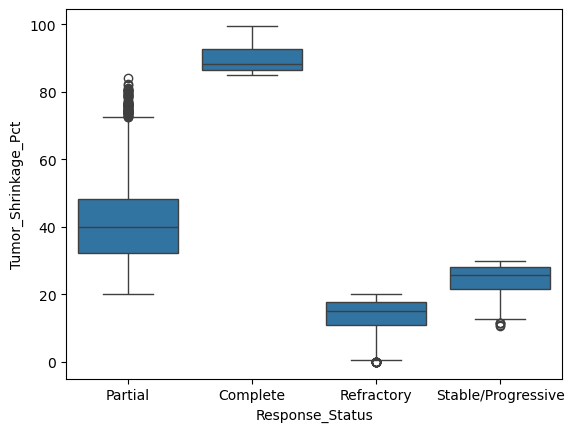

In [22]:
sns.boxplot(x='Response_Status', y='Tumor_Shrinkage_Pct', data=cleaned_df)
plt.show()

Tumor shrinkage clearly separates response groups, confirming it as the strongest predictor of treatment effectiveness.

### CA15-3 Levels vs Response

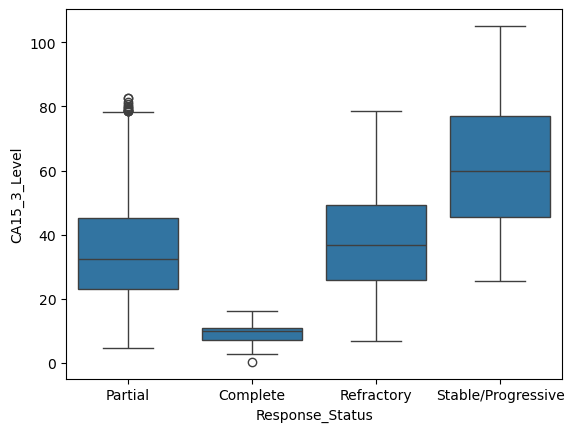

In [23]:
sns.boxplot(x='Response_Status', y='CA15_3_Level', data=cleaned_df)
plt.show()

Higher CA15-3 levels are strongly associated with poorer outcomes, suggesting its role as a predictive biomarker.

### Insight

Treatment effectiveness varies across regimens.
Some regimens demonstrate higher proportions of complete responses,
indicating potential superiority for specific patient groups.

In [24]:
pd.crosstab(
    cleaned_df['Regimen'],
    cleaned_df['Response_Status'],
    normalize='index'
)

Response_Status,Complete,Partial,Refractory,Stable/Progressive
Regimen,,,,
AC-T (Adriamycin/Cytoxan/Taxol),0.007203,0.883153,0.000000,0.109644
Docetaxel + Carboplatin,0.000000,0.799757,0.200243,0.000000
Exemestane,0.000000,0.803862,0.196138,0.000000


### Insight

Response varies significantly across molecular subtypes,
highlighting the importance of tumor biology in treatment outcomes.

In [25]:
pd.crosstab(
    cleaned_df['Molecular_Subtype'],
    cleaned_df['Response_Status'],
    normalize='index'
)

Response_Status,Complete,Partial,Refractory,Stable/Progressive
Molecular_Subtype,,,,
HER2-Enriched,0.011594,0.869565,0.100000,0.018841
Luminal A,0.000000,0.833621,0.095690,0.070690
Luminal B,0.000000,0.819920,0.103622,0.076459
Triple-Negative,0.010246,0.869877,0.098361,0.021516


BRCA mutation appears to influence treatment response,
suggesting potential for personalized treatment strategies.

In [26]:
pd.crosstab(
    cleaned_df['BRCA_Mutation'],
    cleaned_df['Response_Status'],
    normalize='index'
)

Response_Status,Complete,Partial,Refractory,Stable/Progressive
BRCA_Mutation,,,,
0,0.002966,0.843258,0.100616,0.053160
1,0.008375,0.840871,0.082077,0.068677


Tumor shrinkage tends to improve across treatment rounds,
indicating cumulative treatment effects.

In [27]:
cleaned_df.groupby('Treatment_Round')['Tumor_Shrinkage_Pct'].mean()

Treatment_Round
1    45.119684
2    30.203881
Name: Tumor_Shrinkage_Pct, dtype: float64

In [14]:
numeric_df = cleaned_df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()
print(corr_matrix)

                       Treatment_Round  Tumor_Shrinkage_Pct  CA15_3_Level  \
Treatment_Round               1.000000            -0.508457     -0.381046   
Tumor_Shrinkage_Pct          -0.508457             1.000000     -0.226831   
CA15_3_Level                 -0.381046            -0.226831      1.000000   
Side_Effect_Severity         -0.516612             0.266197      0.195111   
Age_at_Diagnosis              0.000503             0.008619     -0.004770   
BRCA_Mutation                -0.001757            -0.012842      0.010008   
Tumor_Grade                   0.000506            -0.008512      0.026010   
Initial_Tumor_Size_mm        -0.000178            -0.020438      0.005575   

                       Side_Effect_Severity  Age_at_Diagnosis  BRCA_Mutation  \
Treatment_Round                   -0.516612          0.000503      -0.001757   
Tumor_Shrinkage_Pct                0.266197          0.008619      -0.012842   
CA15_3_Level                       0.195111         -0.004770     

Most variables show weak linear relationships, suggesting that:
- non-linear models may perform better
- individual features alone may not strongly explain treatment response

A moderate relationship between CA15-3 and tumor shrinkage suggests potential clinical relevance.

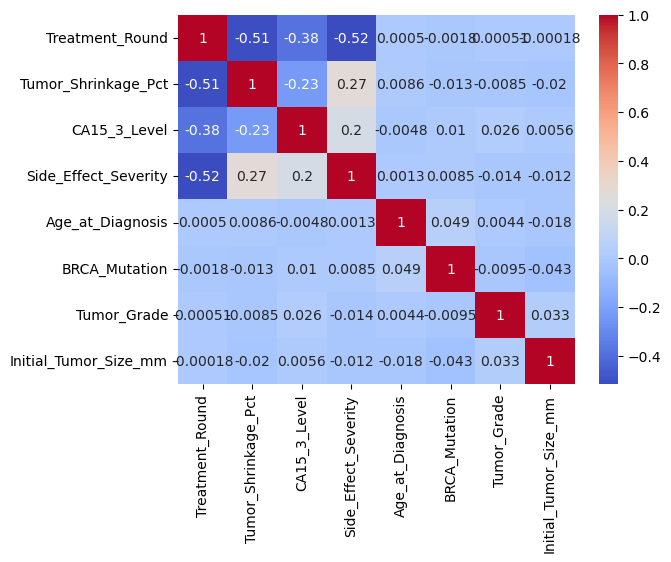

In [28]:
sns.heatmap(cleaned_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Most relationships are weakly linear, suggesting:
- non-linear interactions between variables  
- need for tree-based models  

Single features alone may not fully explain treatment response.

## Key Insights

- Tumor shrinkage is the strongest predictor of response  
- High CA15-3 levels are associated with poor outcomes  
- Treatment effectiveness varies across regimens  
- Molecular subtype significantly impacts response  
- Tumor size influences treatment success  
- Response depends on multiple interacting factors  

## Implications for Modeling

- Use tree-based models (Random Forest, XGBoost)  
- Create interaction features  
- Address class imbalance  